# LZ ER analysis 

Combine the two data sets of the WS2022 and WS2024 data taking campaigns.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm 

#### Loading the data sets

In [2]:
LZdata22 = np.genfromtxt('../data/exps/LZ2025/WS2022_data_hist_data.txt', skip_header=1, delimiter=' ')
LZdata24 = np.genfromtxt('../data/exps/LZ2025/WS2024_data_hist_data.txt', skip_header=1, delimiter=' ')

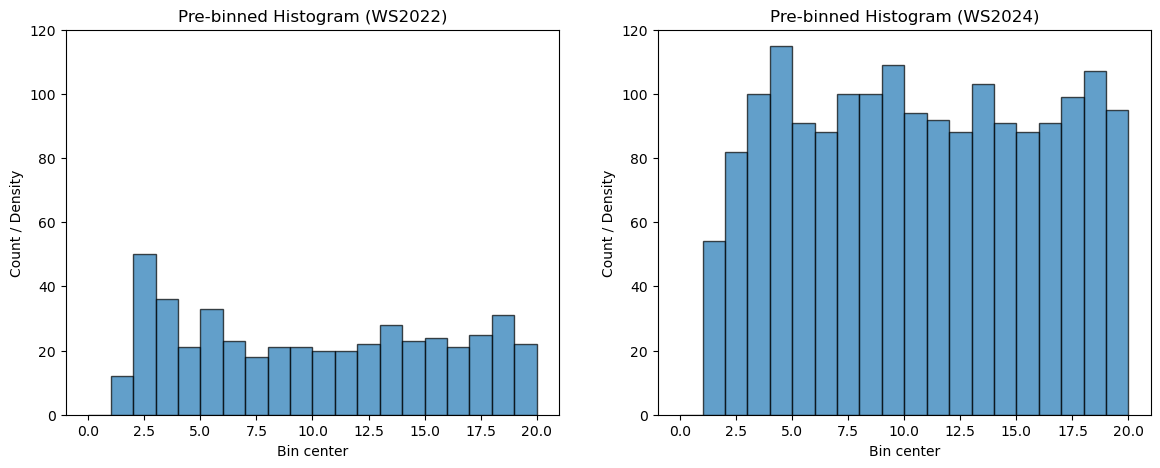

In [3]:
# Assuming your loaded array is called 'data'
bin_centers = LZdata24[:, 0]   # column 1: bin centers (or edges)
heights22 = LZdata22[:, 1]       # column 2: counts/density
heights24 = LZdata24[:, 1]       # column 2: counts/density

# If column 1 is bin CENTERS, you need the width:
# Option A: Assume uniform width from spacing
bin_width = bin_centers[1] - bin_centers[0]  # if uniform spacing


# Joint plot
fig = plt.figure(figsize=(14, 5))

# WS22
ax1 = fig.add_subplot(121)

plt.bar(bin_centers, heights22, width=bin_width, 
        edgecolor='black', alpha=0.7, align='center')
plt.xlabel('Bin center')
plt.ylabel('Count / Density')
plt.title('Pre-binned Histogram (WS2022)')
plt.ylim(0,120)

# WS24
ax2 = fig.add_subplot(122)

plt.bar(bin_centers, heights24, width=bin_width, 
        edgecolor='black', alpha=0.7, align='center')
plt.xlabel('Bin center')
plt.ylabel('Count / Density')
plt.title('Pre-binned Histogram (WS2024)')
plt.ylim(0,120)

plt.show()

#### Loading background fits

In [66]:
LZ_bkg_fit22 = np.genfromtxt('../data/exps/LZ2025/BKG_FIT_WS2022.csv', delimiter=',')
LZ_bkg_fit24 = np.genfromtxt('../data/exps/LZ2025/BKG_FIT_WS2024.csv', delimiter=',')

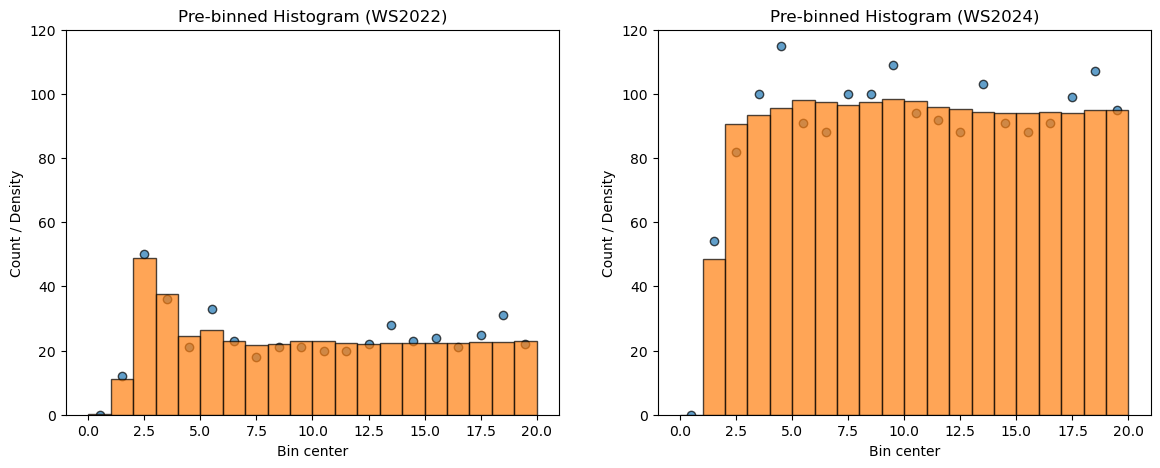

In [5]:
# Joint plot
fig = plt.figure(figsize=(14, 5))

# WS22
ax1 = fig.add_subplot(121)

plt.scatter(bin_centers, heights22, 
        edgecolor='black', alpha=0.7)
plt.bar(bin_centers, LZ_bkg_fit22[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center')
plt.xlabel('Bin center')
plt.ylabel('Count / Density')
plt.title('Pre-binned Histogram (WS2022)')
plt.ylim(0,120)

# WS24
ax2 = fig.add_subplot(122)

plt.scatter(bin_centers, heights24, 
        edgecolor='black', alpha=0.7)
plt.bar(bin_centers, LZ_bkg_fit24[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center')
plt.xlabel('Bin center')
plt.ylabel('Count / Density')
plt.title('Pre-binned Histogram (WS2024)')
plt.ylim(0,120)

plt.show()

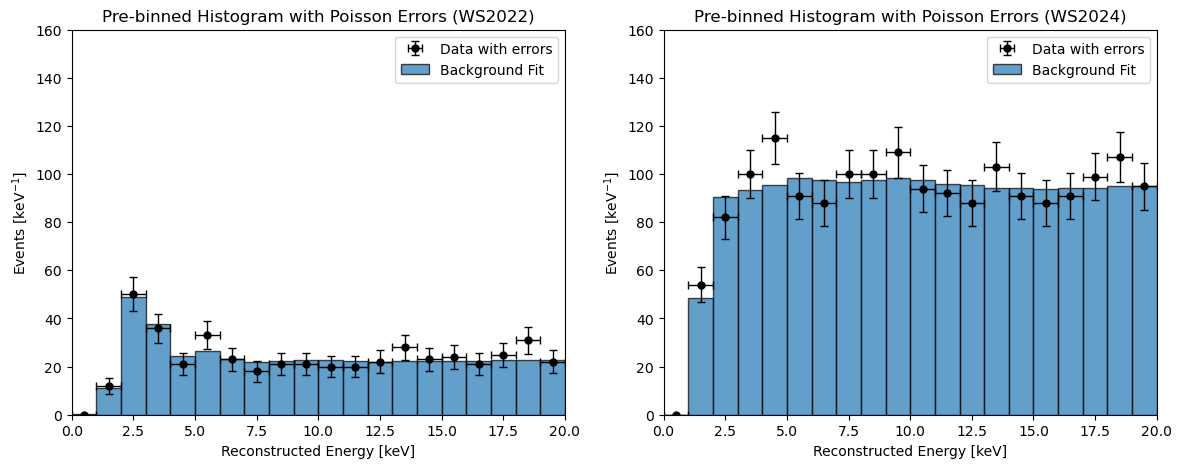

In [6]:
y_err22 = np.sqrt(heights22)
y_err24 = np.sqrt(heights24)

# X-error: half bin width on each side (so bars span the full bin)
x_err = bin_width / 2


# Joint plot
fig = plt.figure(figsize=(14, 5))

# WS22
ax1 = fig.add_subplot(121)

# Plot with error bars
plt.errorbar(bin_centers, heights22, 
             xerr=x_err, yerr=y_err22,
             fmt='o',              # marker style (like scatter)
             capsize=3,            # cap size on error bars
             capthick=1,           # cap thickness
             elinewidth=1,         # error bar line width
             markersize=5,
             label='Data with errors',
             color='black')

# Your fit curve
plt.bar(bin_centers, LZ_bkg_fit22[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label='Background Fit')

plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
plt.ylim(0,160)
plt.xlim(0.0,20.0)
plt.title('Pre-binned Histogram with Poisson Errors (WS2022)')
plt.legend()



# WS22
ax2 = fig.add_subplot(122)

# Plot with error bars
plt.errorbar(bin_centers, heights24, 
             xerr=x_err, yerr=y_err24,
             fmt='o',              # marker style (like scatter)
             capsize=3,            # cap size on error bars
             capthick=1,           # cap thickness
             elinewidth=1,         # error bar line width
             markersize=5,
             label='Data with errors',
             color='black')

# Your fit curve
plt.bar(bin_centers, LZ_bkg_fit24[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label='Background Fit')

plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
plt.ylim(0,160)
plt.xlim(0.0,20.0)
plt.title('Pre-binned Histogram with Poisson Errors (WS2024)')
plt.legend()

plt.show()

### Produce the signal 

In [10]:
from snudd import config
from snudd.targets import Electron      # the elctron target class object
from snudd.binding import binding_xe    # dataclass of binding energy data for xenon and argon
from snudd.rrpa    import rrpa_scaling  # ad-hoc rrpa scaling for bound electron
from snudd.models  import GeneralNSI, SM    # Generic NSI model
from snudd.targets import Nucleus       # Still need a nucleus to be declared
from snudd.resolution import Resolution, Convolver # deals with the resolution effects on the rate

In [11]:
from snudd.efficiencies import efficiency_lz_er_WS22, efficiency_lz_er_WS24
from snudd.resolution   import res_lz_er ## not sure if this should be updated 


E_Rs = np.logspace(-2, 2, 1000) / 1e6  # Recoil energy in GeV, needed for the convolution to be broader than the bin considered


# Testing SM frist
sm_model = SM()

# Setting up the target
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 

Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling) 
Xe_electron.update_model(sm_model)
Xe_electron.prepare_density()

sm_spec_xe = Xe_electron.spectrum(E_Rs) 

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


The exposure for LZ WS2022 is $0.9\,{\rm tonne-years}$ (60 live days, 5.5t fiducial) <br>
The exposure for LZ WS2024 is $3.3\,{\rm tonne-years}$ 

In [ ]:
# Reconstructed events in LZ WS2022 and WS2024


def counts_lz_ER22(signal, E_Rs, E1, E2):
    exposure = 0.9 # in tn yr-1
    convolution_lz_sig= Convolver(E_Rs, signal , efficiency_lz_er_WS22, res_lz_er)
    
    return convolution_lz_sig.convolved_binned_rate(E1, E2)*exposure


def counts_lz_ER24(signal, E_Rs, E1, E2):
    exposure = 3.3 # in tn yr-1
    convolution_lz_sig= Convolver(E_Rs, signal , efficiency_lz_er_WS24, res_lz_er)
    
    return convolution_lz_sig.convolved_binned_rate(E1, E2)*exposure


print(counts_lz_ER22(sm_spec_xe, E_Rs, (bin_centers[0]- bin_width/2)*1e-6, (bin_centers[0] + bin_width/2)*1e-6))
print(counts_lz_ER24(sm_spec_xe, E_Rs, (bin_centers[0]- bin_width/2)*1e-6, (bin_centers[0] + bin_width/2)*1e-6))

0.1280665660450577
0.49179136199997514


In [14]:
counts_sm22 = [counts_lz_ER22(sm_spec_xe, E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers]
counts_sm24 = [counts_lz_ER24(sm_spec_xe, E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers]

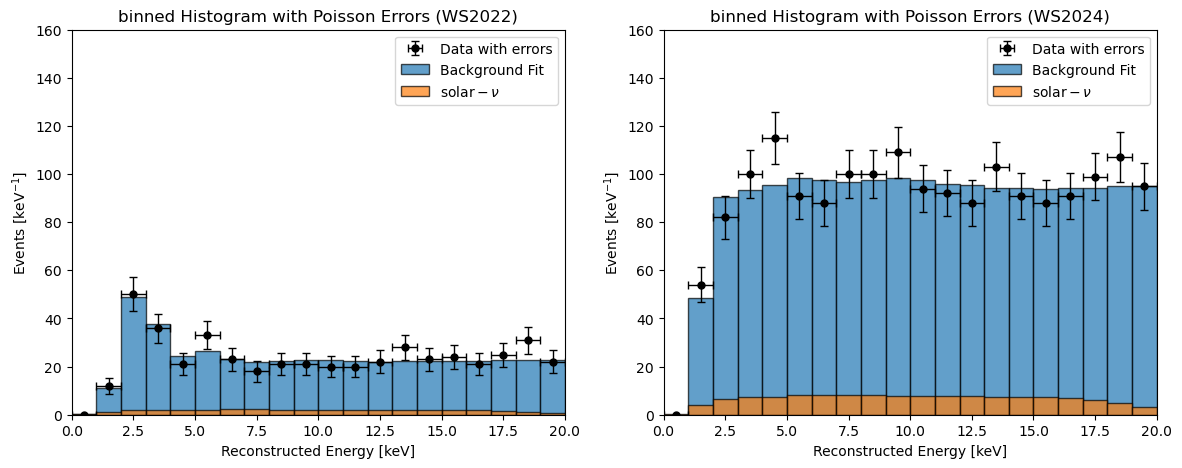

In [35]:
y_err22 = np.sqrt(heights22)
y_err24 = np.sqrt(heights24)

# X-error: half bin width on each side (so bars span the full bin)
x_err = bin_width / 2


# Joint plot
fig = plt.figure(figsize=(14, 5))

# WS22
ax1 = fig.add_subplot(121)

# Plot with error bars
plt.errorbar(bin_centers, heights22, 
             xerr=x_err, yerr=y_err22,
             fmt='o',              # marker style (like scatter)
             capsize=3,            # cap size on error bars
             capthick=1,           # cap thickness
             elinewidth=1,         # error bar line width
             markersize=5,
             label='Data with errors',
             color='black')

# Your fit curve
plt.bar(bin_centers, LZ_bkg_fit22[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label='Background Fit')

plt.bar(bin_centers, counts_sm22, width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label=r'${\rm solar-}\nu$')

plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
plt.ylim(0,160)
plt.xlim(0.0,20.0)
plt.title('binned Histogram with Poisson Errors (WS2022)')
plt.legend()


# WS22
ax2 = fig.add_subplot(122)

# Plot with error bars
plt.errorbar(bin_centers, heights24, 
             xerr=x_err, yerr=y_err24,
             fmt='o',              # marker style (like scatter)
             capsize=3,            # cap size on error bars
             capthick=1,           # cap thickness
             elinewidth=1,         # error bar line width
             markersize=5,
             label='Data with errors',
             color='black')

# Your fit curve
plt.bar(bin_centers, LZ_bkg_fit24[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label='Background Fit')

plt.bar(bin_centers, counts_sm24, width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label=r'${\rm solar-}\nu$')

plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
plt.ylim(0,160)
plt.xlim(0.0,20.0)
plt.title('binned Histogram with Poisson Errors (WS2024)')
plt.legend()

plt.show()

For the first data set, our predictions are close ($38.1\pm2.3$) <br>
Note, that the total of this result is a little more than what we calculate ($151\pm9$)

In [36]:
print(sum(counts_sm22))
print(sum(counts_sm24))

35.22512868736372
132.61617902645736


## Statistical analysis

This best-fit background includes the solar-$\nu$ background. Assuming out  

In [17]:
bkg_nucor22 = LZ_bkg_fit22[:, 1] - counts_sm22
bkg_nucor24 = LZ_bkg_fit24[:, 1] - counts_sm24

We want to calculate the total rate including a NSI signal, for the ith bin

$$N_{\rm pred}^{i}(\Theta; \alpha)= (1+\alpha)N_{\rm bkg}^{i} + N^i_{\rm NSI}(\Theta)$$

where $\Theta$ is the NSI parameters and $\alpha$ is the nuisance parameter of the background fit. 

Can define the $\chi^2$ as 

$$\chi^2=2\sum^{\rm bins}_{i=1}\left[N_{\rm pred}^i-N_{\rm data}^{i} + N_{\rm data}^i\ln\left(\frac{N_{\rm data}^i}{N_{\rm pred}^i}\right)\right] + \left(\frac{\alpha}{\sigma_{\alpha}}\right)^2$$

So we need to understand the error in the background

In [20]:
# WS2022 1D fit results: (central_value, error) 
ws2022 = {
    "beta_dec_plus_det_gamma":     (336, 20),
    "Xe136_2vbb":                  (27.8, 4.3),
    "Xe127_Xe125_EC":              (9.3, 0.8),
    "Xe124_DEC":                   (5.0, 1.4),
    "Ar37":                        (47.6, 9.4),
    "Acc_coincidence":             (1.2, 0.3) 
}


# WS2024 1D fit results: (central_value, error) 
ws2024 = {
    "Pb214_beta":                  (1096, 46),
    "Kr85_Ar39_betas_det_gammas":  (236, 31),
    "Xe136_2vbb":                  (108, 16),
    "Po218_Pb212_betas":           (93.1, 10.9),
    "H3_C14":                      (62.9, 3.4),
    "Xe124_DEC":                   (19.8, 4.0),
    "Xe127_Xe125_EC":              (2.8, 0.6),
    "Rn_beta_tagging":             (0.62, 0.02) #, "solar_nu_ER": (151, 9),
}

In [37]:
def total_background(components: dict):
    values = np.array([v for v, _ in components.values()])
    errors = np.array([e for _, e in components.values()])
    total_val = values.sum()
    total_err = np.sqrt((errors**2).sum())  # quadrature sum
    return total_val, total_err

total_val_22, total_err_22 = total_background(ws2022)
total_val_24, total_err_24 = total_background(ws2024)

rel_unc22 = total_err_22 / total_val_22
rel_unc24 = total_err_24 / total_val_24

print(f"Total background: {total_val_22:.1f} ± {total_err_22:.1f}")
print(f"Total background: {total_val_24:.1f} ± {total_err_24:.1f}")
print(f"Relative uncertainty 2022: {rel_unc22:.3f}")
print(f"Relative uncertainty 2024: {rel_unc24:.3f}")

Total background: 426.9 ± 22.6
Total background: 1619.2 ± 59.0
Relative uncertainty 2022: 0.053
Relative uncertainty 2024: 0.036


I will assume that this uncertainty is even for each bin, $\%3.7$

In [49]:
def poisson_chi2(N_nu: np.ndarray, N_bkg: np.ndarray, N_data: np.ndarray, alpha: float = 0.0, sigma_alpha: float = 1.0):
    """
    Compute the Poissonlikelihood-based chi-squared (Cash statistic).

    chi^2 = 2 * sum_i [ N_pred^i - N_data^i + N_data^i * ln(N_data^i / N_pred^i) ] + (alpha / sigma_alpha)^2

    Parameters
    ----------
    N_nu : np.ndarray
        Number of neutrino events in each bin (must be non-negative)
    N_bkg : np.ndarray
        Number of background events in each bin (must be non-negative)
    N_data : np.ndarray
        Observed number of events in each bin (must be non-negative)
    alpha : float, optional
        Nuisance parameter (default: 0.0)
    sigma_alpha : float, optional
        Uncertainty on the nuisance parameter (default: 1.0)

    Returns
    -------
    float
        The chi-squared value
    """
    N_pred = np.atleast_1d(N_nu + (1+alpha)*N_bkg)
    N_data = np.atleast_1d(N_data)

    assert len(N_pred) == len(N_data), "N_pred and N_data must have the same length"

    # Handle edge cases:
    # 1. When N_data = 0, the term N_data * ln(N_data / N_pred) -> 0 (limit as x->0 of x*ln x = 0)
    # 2. When N_pred = 0, the log term is problematic - skip these bins
    # 3. Use np.log to compute ln(N_data / N_pred) = ln(N_data) - ln(N_pred)

    valid_mask = N_pred > 0

    if not np.any(valid_mask):
        return np.inf  # all predictions are invalid

    N_pred_valid = N_pred[valid_mask]
    N_data_valid = N_data[valid_mask]

    # Compute term = N_pred - N_data + N_data * ln(N_data / N_pred)
    # For zero bins where N_data = 0, the ln term contributes zero
    term = N_pred_valid - N_data_valid + N_data_valid * (
        np.log(N_data_valid + 1e-300) - np.log(N_pred_valid)  # handles N_data = 0 naturally
    )

    # Sum over bins and multiply by 2
    chi2 = 2.0 * np.sum(term)

    # Add the nuisance parameter penalty term
    chi2 += (alpha / sigma_alpha)**2

    return chi2

In [53]:
poisson_chi2(counts_sm24, bkg_nucor24, heights24)

np.float64(12.452759803304035)

## 1D scan 

In [38]:
eps_space = np.geomspace(1e-1, 0.5, 10)
eta = 0.0 # therefore in the proton-neutron plane
phi = np.pi/2 # therefore in the electron direction   




In [39]:
from snudd.nsi import utils

def set_NSI_params(eps, eta, phi):
    
    eps_matrix = np.array([[0., 1.0, 0.], [1.0, 0.0, 0.], [0., 0, 0.0]]) * eps # eps_{e\mu} can change this structure 
    eps_matrix = utils.eps_matrix_sym(eps_matrix)
    nsi_model = GeneralNSI(eps_matrix, eta, phi)
    
    return nsi_model

### Without profiling

In [52]:
# Initialize a 2D array: shape (n_eps, n_bins)
counts_all22 = np.zeros((len(eps_space), len(bin_centers)))
counts_all24 = np.zeros((len(eps_space), len(bin_centers)))

for i, eps in enumerate(tqdm(eps_space, desc="Processing eps values")):
    NSI_eps_tmp = eps
    NSI_eta_tmp = eta  # fixed as zero
    NSI_phi_tmp = phi  # fixed as zero

    nsi_temp = set_NSI_params(NSI_eps_tmp, NSI_eta_tmp, NSI_phi_tmp)
    Xe_electron.update_model(nsi_temp)
    Xe_electron.prepare_density()

    signal_temp = Xe_electron.spectrum(E_Rs) 
    # Compute binned counts for this eps value
    counts_all22[i, :] = np.array([counts_lz_ER22(signal_temp, E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers])
    counts_all24[i, :] = np.array([counts_lz_ER24(signal_temp, E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers])


Processing eps values:   0%|          | 0/10 [00:00<?, ?it/s]

Processing eps values: 100%|██████████| 10/10 [00:06<00:00,  1.64it/s]


In [54]:
counts_all24[1, :]

array([0.54181397, 4.25913907, 7.31426871, 7.99111856, 8.31322384,
       8.77882745, 8.98168804, 8.9420972 , 8.85012042, 8.74330009,
       8.62554198, 8.50337163, 8.38098516, 8.25333033, 8.09694913,
       7.85240947, 7.40663414, 6.59760285, 5.2937569 , 3.59129282])

In [57]:
chi2_values = np.zeros(len(eps_space)) 

for i in range(len(eps_space)):
    chi2_values[i] = poisson_chi2(counts_all22[i, :], bkg_nucor22, heights22) + poisson_chi2(counts_all24[i, :], bkg_nucor24, heights24)

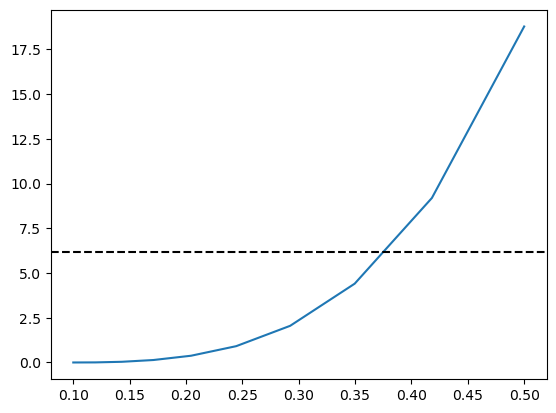

In [58]:
plt.plot(eps_space, chi2_values-np.min(chi2_values))
plt.axhline(6.18, color='k', ls='--')


### With profiling

To marginalize over the nuisance $\alpha$ I need to minimize the $\chi^2$ w.r.t. $\alpha$ 

In [59]:
from scipy.optimize import minimize_scalar

chi2_alpha_values = np.zeros(len(eps_space)) 

for i in range(len(eps_space)):
    result22 = minimize_scalar(fun = lambda a: poisson_chi2(counts_all22[i, :], bkg_nucor22, heights22, alpha=a, sigma_alpha=rel_unc22), bounds=(-5, 5), method='bounded')
    result24 = minimize_scalar(fun = lambda a: poisson_chi2(counts_all24[i, :], bkg_nucor24, heights24, alpha=a, sigma_alpha=rel_unc24), bounds=(-5, 5), method='bounded')
    chi2_alpha_values[i] = result22.fun + result24.fun

Text(0, 0.5, '$\\chi^2 - \\chi^2_{\\rm min}$')

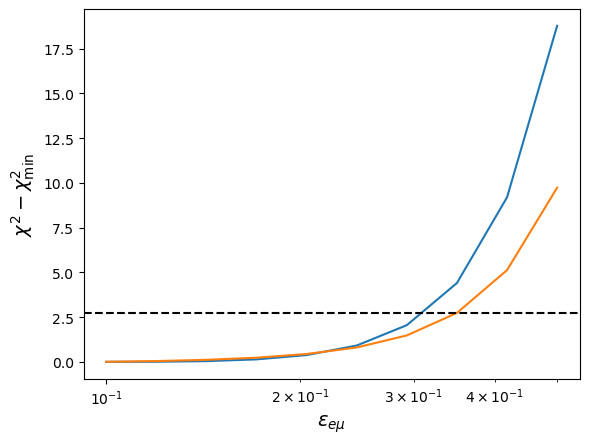

In [60]:
plt.semilogx(eps_space, chi2_values-np.min(chi2_values))
plt.semilogx(eps_space, chi2_alpha_values-np.min(chi2_alpha_values))

plt.axhline(2.71, color='k', ls='--')

plt.xlabel(r'$\epsilon_{e\mu}$', size=14)
plt.ylabel(r'$\chi^2 - \chi^2_{\rm min}$', size=14)

In [61]:
counts_summed = np.zeros(len(eps_space)) 

for i in range(len(eps_space)):
    counts_summed[i] = counts_all24[i, :].sum()

Text(0, 0.5, '${\\rm Events}$')

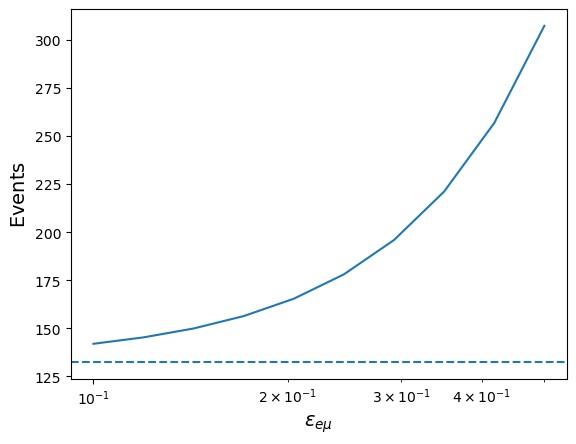

In [62]:
plt.semilogx(eps_space, counts_summed)
plt.axhline(sum(counts_sm24), ls='--')

plt.xlabel(r'$\epsilon_{e\mu}$', size=14)
plt.ylabel(r'${\rm Events}$', size=14)